In [1]:
# Import libraries
# We need pandas for data manipulation
# numpy for numerical calculations
# matplotlib and seaborn for visualization
# scipy for statistical tests
# re for text searching

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load dataset
# We load the same MIMIC-III dataset we used for LPBA and PA
# This time we are not using ClinicalBERT at all
# We are working directly with the text of the clinical notes

df = pd.read_csv(
    r"C:\Users\kehin\thesis project\data\MIMICIII_Cleaned_Merged.csv",
    on_bad_lines='skip',
    engine='python',
    encoding='utf-8'
)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (1176, 21)
Columns: ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'CHARTDATE', 'CHARTTIME', 'STORETIME', 'CATEGORY', 'DESCRIPTION', 'CGID', 'ISERROR', 'TEXT', 'word_non_compliant', 'word_resistant', 'word_agitated', 'word_uncooperative', 'any_bias_word', 'ETHNICITY', 'GENDER', 'DOB', 'DOD', 'EXPIRE_FLAG']


In [3]:
# Consolidate ethnicity and filter
# Same ethnicity mapping we used in LPBA and PA
# We need consistent demographic group labels across all three analyses

ethnicity_map = {
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'BLACK/AFRICAN AMERICAN': 'Black',
    'BLACK/AFRICAN': 'Black',
    'HISPANIC OR LATINO': 'Hispanic',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic',
    'HISPANIC/LATINO - COLOMBIAN': 'Hispanic',
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - VIETNAMESE': 'Asian'
}

df['RACE_GROUP'] = df['ETHNICITY'].map(ethnicity_map)
df['GENDER_GROUP'] = df['GENDER'].map({'M': 'Male', 'F': 'Female'})
df_filtered = df[df['RACE_GROUP'].notna()].copy()

print("Filtered shape:", df_filtered.shape)
print("\nRace distribution:")
print(df_filtered['RACE_GROUP'].value_counts())
print("\nGender distribution:")
print(df_filtered['GENDER_GROUP'].value_counts())

Filtered shape: (1065, 23)

Race distribution:
RACE_GROUP
White       890
Black       130
Hispanic     24
Asian        21
Name: count, dtype: int64

Gender distribution:
GENDER_GROUP
Male      595
Female    470
Name: count, dtype: int64


In [4]:
# Define target words from significant LPBA and PA findings
# We focus on words that showed significant differences in our model analysis
# because these are the words where corpus frequency comparison matters most

# LPBA significant words
lpba_words = [
    "agitated", "compliance", "refused", "oriented", 
    "difficult", "confused", "cooperative", "refusing"
]

# PA significant words
pa_words = [
    "requested", "agreed", "declined", "presented"
]

# All target words combined
all_target_words = list(set(lpba_words + pa_words))

print("LPBA significant words:", lpba_words)
print("PA significant words:", pa_words)
print("Total unique words:", len(all_target_words))

LPBA significant words: ['agitated', 'compliance', 'refused', 'oriented', 'difficult', 'confused', 'cooperative', 'refusing']
PA significant words: ['requested', 'agreed', 'declined', 'presented']
Total unique words: 12


In [5]:
# Count word frequency per demographic group
# For each word we count how many notes in each demographic group
# contain that word at least once
# We also calculate the rate by dividing by total notes per group

print("Counting word frequency per demographic group...\n")

# First get total notes per race group
# This is our denominator for calculating rates
notes_per_race = df_filtered['RACE_GROUP'].value_counts()
print("Total notes per race group:")
print(notes_per_race)
print()

# Now count how many notes per race group contain each target word
frequency_results = []

for word in all_target_words:
    for race in ['White', 'Black', 'Hispanic', 'Asian']:
        # Get all notes for this race group
        race_notes = df_filtered[
            df_filtered['RACE_GROUP'] == race
        ]['TEXT'].dropna()
        
        # Count notes containing the word
        # We use str.contains to find the word as a whole word
        # case=False means we match regardless of capitalization
        word_count = race_notes.str.contains(
            r'\b' + word + r'\b',
            case=False,
            regex=True
        ).sum()
        
        # Calculate rate as percentage of notes containing the word
        total_notes = notes_per_race[race]
        rate = (word_count / total_notes) * 100
        
        frequency_results.append({
            "Word": word,
            "Race": race,
            "Note_Count": word_count,
            "Total_Notes": total_notes,
            "Rate_Percent": rate,
            "Source": "LPBA" if word in lpba_words else "PA"
        })
freq_df = pd.DataFrame(frequency_results)
print("Word frequency analysis complete")
print(f"Total observations: {len(freq_df)}")

Counting word frequency per demographic group...

Total notes per race group:
RACE_GROUP
White       890
Black       130
Hispanic     24
Asian        21
Name: count, dtype: int64

Word frequency analysis complete
Total observations: 48


In [6]:
# Display frequency table
# This shows us the raw counts and rates for each word
# across all demographic groups in a readable format

print("Word Frequency by Race Group\n")

freq_pivot = freq_df.pivot_table(
    index='Word',
    columns='Race',
    values='Rate_Percent',
    aggfunc='mean'
).round(2)

# Reorder columns for consistency with LPBA and PA
freq_pivot = freq_pivot[['White', 'Black', 'Hispanic', 'Asian']]

print("Rate (percentage of notes containing word):\n")
print(freq_pivot.to_string())

print("\nRaw Counts\n")
count_pivot = freq_df.pivot_table(
    index='Word',
    columns='Race',
    values='Note_Count',
    aggfunc='mean'
).round(0)
count_pivot = count_pivot[['White', 'Black', 'Hispanic', 'Asian']]
print(count_pivot.to_string())

Word Frequency by Race Group

Rate (percentage of notes containing word):

Race         White  Black  Hispanic  Asian
Word                                      
agitated      4.38   4.62      4.17   0.00
agreed        5.17   5.38      8.33   0.00
compliance    5.17   7.69      4.17   9.52
confused     10.56  10.00      8.33   4.76
cooperative   4.61   3.08     12.50   4.76
declined      5.96   8.46      4.17   4.76
difficult    17.08  22.31     12.50  19.05
oriented     38.20  41.54     41.67  33.33
presented    41.91  50.77     37.50  38.10
refused       7.75  15.38     12.50   0.00
refusing      1.69   6.15      0.00   0.00
requested     4.49   8.46      4.17   0.00

Raw Counts

Race         White  Black  Hispanic  Asian
Word                                      
agitated      39.0    6.0       1.0    0.0
agreed        46.0    7.0       2.0    0.0
compliance    46.0   10.0       1.0    2.0
confused      94.0   13.0       2.0    1.0
cooperative   41.0    4.0       3.0    1.0
declined 

In [7]:
# Load LPBA and PA significant results
# We bring in the model probability findings from our earlier analyses
# so we can compare them directly against the corpus frequencies

lpba_sig = pd.read_csv(
    r"C:\Users\kehin\thesis project\data\LPBA_significant_results.csv"
)
pa_sig = pd.read_csv(
    r"C:\Users\kehin\thesis project\data\PA_significant_results.csv"
)

print("LPBA significant results loaded:")
print(lpba_sig[['Target_Word', 'Minority_Group', 'Mean_Difference', 'p_value']].to_string(index=False))
print("\nPA significant results loaded:")
print(pa_sig[['Target_Word', 'Comparison_Group', 'Mean_Difference', 'p_value']].to_string(index=False))

LPBA significant results loaded:
  Target_Word Minority_Group  Mean_Difference  p_value
  cooperative          Black         0.049236 0.480553
  cooperative       Hispanic        -0.051326 0.664534
  cooperative          Asian         0.047439 0.608063
   compliance          Black        -0.447333 0.008362
   compliance       Hispanic         0.026363 0.771305
   compliance          Asian         0.297490 0.116043
      refused          Black        -0.122932 0.052125
      refused       Hispanic        -0.114514 0.013064
      refused          Asian        -0.062653 0.183569
     refusing          Black         0.080779 0.127624
     refusing       Hispanic        -0.011315 0.893625
     refusing          Asian         0.043367 0.530222
     oriented          Black         0.006177 0.046813
     oriented       Hispanic        -0.014761 0.053631
     oriented          Asian        -0.013514 0.016833
    difficult          Black        -0.005024 0.481507
    difficult       Hispanic    

In [8]:
# Calculate corpus rate differences from White reference
# For each word we calculate how much higher or lower
# the minority group rate is compared to the White rate
# This gives us a corpus-level measure to compare against
# the model probability differences

print("Corpus Rate Differences from White Reference\n")

corpus_diff_results = []

for word in all_target_words:
    white_rate = freq_df[
        (freq_df['Word'] == word) &
        (freq_df['Race'] == 'White')
    ]['Rate_Percent'].values[0]
    
    for race in ['Black', 'Hispanic', 'Asian']:
        minority_rate = freq_df[
            (freq_df['Word'] == word) &
            (freq_df['Race'] == race)
        ]['Rate_Percent'].values[0]
        
        rate_difference = minority_rate - white_rate
        
        corpus_diff_results.append({
            "Word": word,
            "Minority_Group": race,
            "White_Rate": white_rate,
            "Minority_Rate": minority_rate,
            "Rate_Difference": rate_difference,
            "Direction": "higher" if rate_difference > 0 else "lower"
        })
        
        print(f"{word} | White vs {race}: "
              f"White={white_rate:.2f}%, {race}={minority_rate:.2f}% | "
              f"Difference={rate_difference:+.2f}%")
    print()

corpus_diff_df = pd.DataFrame(corpus_diff_results)
corpus_diff_df.to_csv(
    r"C:\Users\kehin\thesis project\data\RQ3_corpus_differences.csv",
    index=False
)
print("Corpus differences saved")

Corpus Rate Differences from White Reference

agreed | White vs Black: White=5.17%, Black=5.38% | Difference=+0.22%
agreed | White vs Hispanic: White=5.17%, Hispanic=8.33% | Difference=+3.16%
agreed | White vs Asian: White=5.17%, Asian=0.00% | Difference=-5.17%

difficult | White vs Black: White=17.08%, Black=22.31% | Difference=+5.23%
difficult | White vs Hispanic: White=17.08%, Hispanic=12.50% | Difference=-4.58%
difficult | White vs Asian: White=17.08%, Asian=19.05% | Difference=+1.97%

confused | White vs Black: White=10.56%, Black=10.00% | Difference=-0.56%
confused | White vs Hispanic: White=10.56%, Hispanic=8.33% | Difference=-2.23%
confused | White vs Asian: White=10.56%, Asian=4.76% | Difference=-5.80%

compliance | White vs Black: White=5.17%, Black=7.69% | Difference=+2.52%
compliance | White vs Hispanic: White=5.17%, Hispanic=4.17% | Difference=-1.00%
compliance | White vs Asian: White=5.17%, Asian=9.52% | Difference=+4.36%

oriented | White vs Black: White=38.20%, Black=41

In [9]:
# Compare corpus frequency against model probability
# This is the core RQ3 analysis
# For each significant model finding we check whether
# the corpus frequency difference goes in the same direction
# as the model probability difference
# 
# Same direction = statistical disparity 
# the model reflects what is in the training data
#
# Opposite direction = bias amplification or suppression
# the model is doing something beyond what the data contains

print("RQ3: Corpus Frequency vs Model Probability Comparison\n")
print("Comparing direction of corpus frequency difference against model probability difference\n")

comparison_results = []

# First do LPBA words
print("PBA Significant Findings\n")
for _, row in lpba_sig.iterrows():
    word = row['Target_Word']
    minority = row['Minority_Group']
    model_diff = row['Mean_Difference']
    model_direction = "higher" if model_diff > 0 else "lower"
    
    corpus_row = corpus_diff_df[
        (corpus_diff_df['Word'] == word) &
        (corpus_diff_df['Minority_Group'] == minority)
    ]
    
    if len(corpus_row) > 0:
        corpus_diff = corpus_row['Rate_Difference'].values[0]
        corpus_direction = "higher" if corpus_diff > 0 else "lower"
        
        alignment = "REFLECTS corpus" if model_direction == corpus_direction else "CONTRADICTS corpus"
        
        comparison_results.append({
            "Word": word,
            "Minority_Group": minority,
            "Model_Difference": model_diff,
            "Model_Direction": model_direction,
            "Corpus_Rate_Difference": corpus_diff,
            "Corpus_Direction": corpus_direction,
            "Alignment": alignment,
            "Method": "LPBA"
        })
        
        print(f"{word} | {minority}")
        print(f"  Model: {minority} {model_direction} prob than White (diff={model_diff:+.3f})")
        print(f"  Corpus: {minority} {corpus_direction} rate than White (diff={corpus_diff:+.2f}%)")
        print(f"  → {alignment}\n")

# Then do PA words
print("--- PA Significant Findings ---\n")
for _, row in pa_sig.iterrows():
    word = row['Target_Word']
    minority = row['Comparison_Group'].replace(' Male', '').replace(' Female', '')
    model_diff = row['Mean_Difference']
    model_direction = "higher" if model_diff > 0 else "lower"
    
    corpus_row = corpus_diff_df[
        (corpus_diff_df['Word'] == word) &
        (corpus_diff_df['Minority_Group'] == minority)
    ]
    
    if len(corpus_row) > 0:
        corpus_diff = corpus_row['Rate_Difference'].values[0]
        corpus_direction = "higher" if corpus_diff > 0 else "lower"
        
        alignment = "REFLECTS corpus" if model_direction == corpus_direction else "CONTRADICTS corpus"
        
        comparison_results.append({
            "Word": word,
            "Minority_Group": row['Comparison_Group'],
            "Model_Difference": model_diff,
            "Model_Direction": model_direction,
            "Corpus_Rate_Difference": corpus_diff,
            "Corpus_Direction": corpus_direction,
            "Alignment": alignment,
            "Method": "PA"
        })
        
        print(f"{word} | {row['Comparison_Group']}")
        print(f"  Model: {row['Comparison_Group']} {model_direction} prob than White (diff={model_diff:+.3f})")
        print(f"  Corpus: {minority} {corpus_direction} rate than White (diff={corpus_diff:+.2f}%)")
        print(f"  → {alignment}\n")

comparison_df = pd.DataFrame(comparison_results)
comparison_df.to_csv(
    r"C:\Users\kehin\thesis project\data\RQ3_comparison_results.csv",
    index=False
)
print("Comparison results saved")
print(f"\nTotal comparisons: {len(comparison_df)}")
print(f"Reflects corpus: {(comparison_df['Alignment'] == 'REFLECTS corpus').sum()}")
print(f"Contradicts corpus: {(comparison_df['Alignment'] == 'CONTRADICTS corpus').sum()}")

RQ3: Corpus Frequency vs Model Probability Comparison

Comparing direction of corpus frequency difference against model probability difference

PBA Significant Findings

cooperative | Black
  Model: Black higher prob than White (diff=+0.049)
  Corpus: Black lower rate than White (diff=-1.53%)
  → CONTRADICTS corpus

cooperative | Hispanic
  Model: Hispanic lower prob than White (diff=-0.051)
  Corpus: Hispanic higher rate than White (diff=+7.89%)
  → CONTRADICTS corpus

cooperative | Asian
  Model: Asian higher prob than White (diff=+0.047)
  Corpus: Asian higher rate than White (diff=+0.16%)
  → REFLECTS corpus

compliance | Black
  Model: Black lower prob than White (diff=-0.447)
  Corpus: Black higher rate than White (diff=+2.52%)
  → CONTRADICTS corpus

compliance | Hispanic
  Model: Hispanic higher prob than White (diff=+0.026)
  Corpus: Hispanic lower rate than White (diff=-1.00%)
  → CONTRADICTS corpus

compliance | Asian
  Model: Asian higher prob than White (diff=+0.297)
  Cor

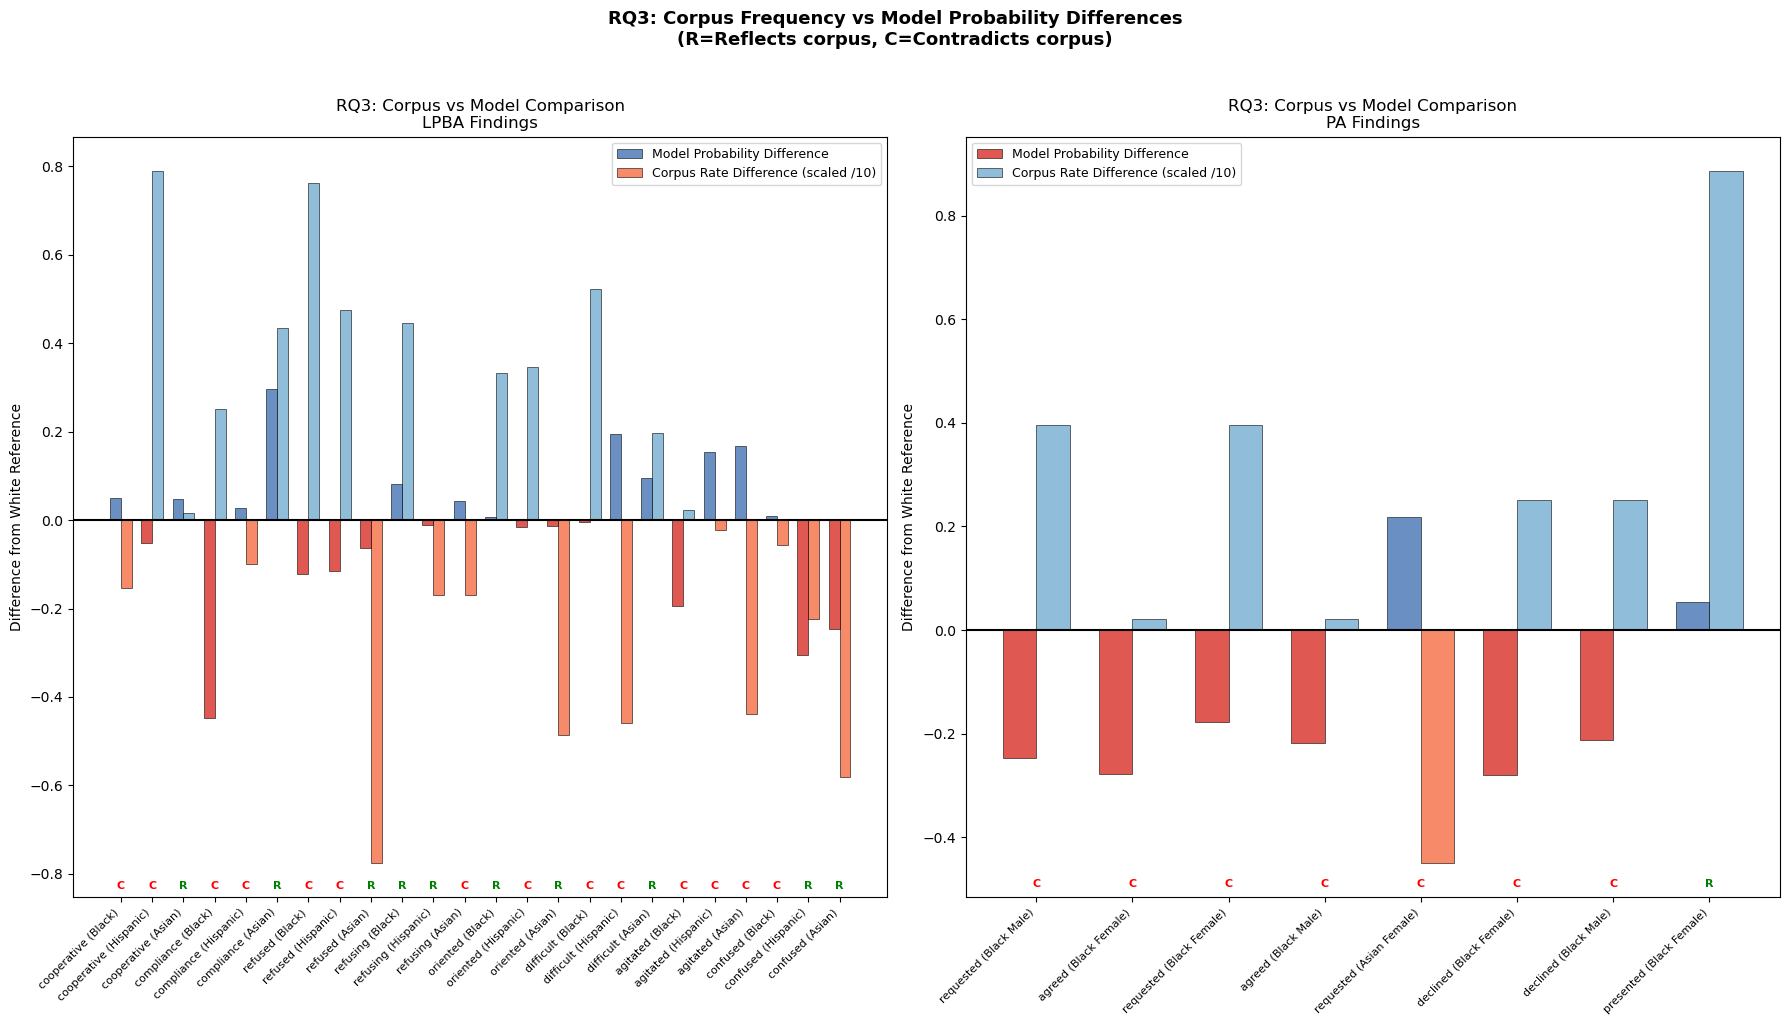

RQ3 comparison chart saved


In [10]:
# Visualization - Corpus Rate vs Model Probability comparison
# This chart shows both the corpus frequency difference and the model
# probability difference for each significant finding side by side
# so the reader can immediately see whether they align or contradict

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Separate LPBA and PA findings
lpba_comp = comparison_df[comparison_df['Method'] == 'LPBA'].copy()
pa_comp = comparison_df[comparison_df['Method'] == 'PA'].copy()

for ax, comp_data, title in zip(
    axes,
    [lpba_comp, pa_comp],
    ['LPBA Findings', 'PA Findings']
):
    comp_data = comp_data.reset_index(drop=True)
    comp_data['Label'] = comp_data['Word'] + ' (' + comp_data['Minority_Group'] + ')'
    
    x = np.arange(len(comp_data))
    width = 0.35
    
    # Normalize corpus rate difference for visual comparison
    # We divide by a scaling factor to make both measures visible
    # on the same chart since they are in different units
    corpus_scaled = comp_data['Corpus_Rate_Difference'] / 10
    model_diff = comp_data['Model_Difference']
    
    bars1 = ax.bar(
        x - width/2,
        model_diff,
        width,
        label='Model Probability Difference',
        color=['#d73027' if v < 0 else '#4575b4' for v in model_diff],
        edgecolor='black',
        linewidth=0.5,
        alpha=0.8
    )
    
    bars2 = ax.bar(
        x + width/2,
        corpus_scaled,
        width,
        label='Corpus Rate Difference (scaled /10)',
        color=['#f46d43' if v < 0 else '#74add1' for v in corpus_scaled],
        edgecolor='black',
        linewidth=0.5,
        alpha=0.8
    )
    
    ax.axhline(y=0, color='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(comp_data['Label'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Difference from White Reference')
    ax.set_title(f'RQ3: Corpus vs Model Comparison\n{title}')
    ax.legend(fontsize=9)
    
    # Add alignment labels
    for i, row in comp_data.iterrows():
        color = 'green' if row['Alignment'] == 'REFLECTS corpus' else 'red'
        label = 'R' if row['Alignment'] == 'REFLECTS corpus' else 'C'
        ax.text(i, ax.get_ylim()[0] + 0.02, label,
               ha='center', fontsize=8, color=color, fontweight='bold')

plt.suptitle(
    'RQ3: Corpus Frequency vs Model Probability Differences\n(R=Reflects corpus, C=Contradicts corpus)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\RQ3_corpus_vs_model.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("RQ3 comparison chart saved")

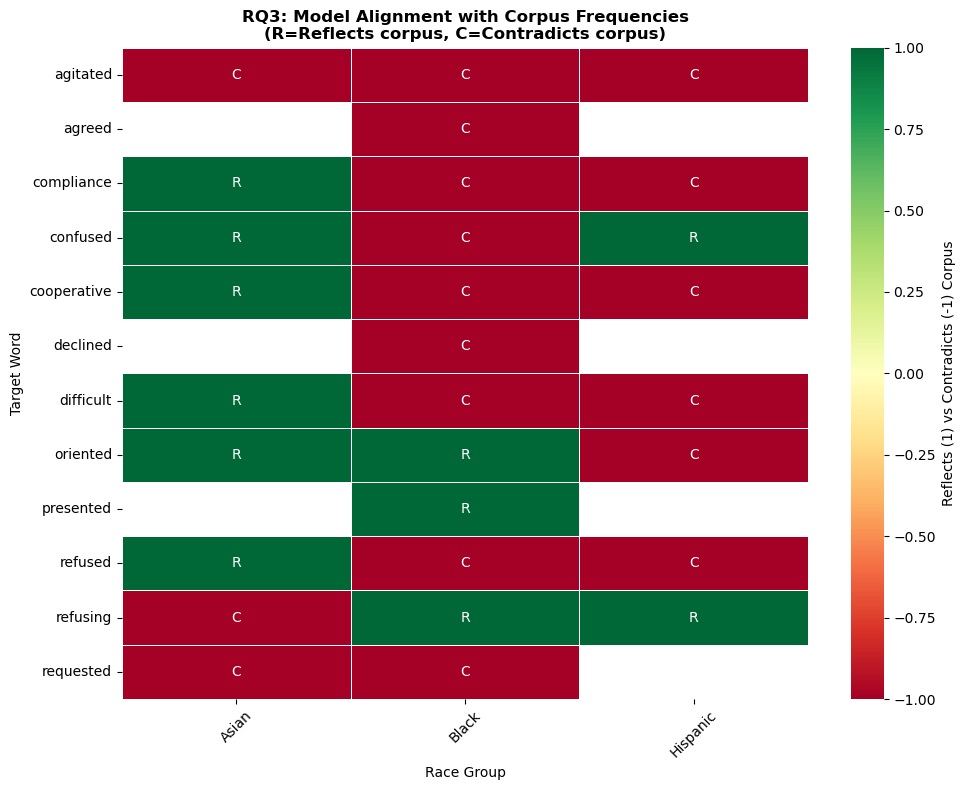

RQ3 alignment heatmap saved


In [11]:
# Summary heatmap showing alignment pattern
# This gives a cleaner overview of which words reflect
# versus contradict the corpus across demographic groups

alignment_data = []

for word in all_target_words:
    for race in ['Black', 'Hispanic', 'Asian']:
        comp_row = comparison_df[
            (comparison_df['Word'] == word) &
            (comparison_df['Minority_Group'].str.contains(race))
        ]
        if len(comp_row) > 0:
            # Use 1 for reflects corpus, -1 for contradicts
            value = 1 if comp_row['Alignment'].iloc[0] == 'REFLECTS corpus' else -1
            alignment_data.append({
                "Word": word,
                "Race": race,
                "Alignment_Score": value,
                "Alignment": comp_row['Alignment'].iloc[0]
            })

alignment_df = pd.DataFrame(alignment_data)
pivot_alignment = alignment_df.pivot_table(
    index='Word',
    columns='Race',
    values='Alignment_Score',
    aggfunc='mean'
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_alignment,
    annot=alignment_df.pivot_table(
        index='Word',
        columns='Race',
        values='Alignment',
        aggfunc=lambda x: 'R' if (x == 'REFLECTS corpus').all() else 'C'
    ),
    fmt='',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Reflects (1) vs Contradicts (-1) Corpus'}
)

plt.title(
    'RQ3: Model Alignment with Corpus Frequencies\n(R=Reflects corpus, C=Contradicts corpus)',
    fontsize=12, fontweight='bold'
)
plt.xlabel('Race Group')
plt.ylabel('Target Word')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\RQ3_alignment_heatmap.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("RQ3 alignment heatmap saved")

In [12]:
# Save summary statistics
print("RQ3 Summary\n")
print(f"Total comparisons: {len(comparison_df)}")
print(f"Reflects corpus: {(comparison_df['Alignment'] == 'REFLECTS corpus').sum()} ({(comparison_df['Alignment'] == 'REFLECTS corpus').mean()*100:.1f}%)")
print(f"Contradicts corpus: {(comparison_df['Alignment'] == 'CONTRADICTS corpus').sum()} ({(comparison_df['Alignment'] == 'CONTRADICTS corpus').mean()*100:.1f}%)")

print("\nAlignment by method:")
print(comparison_df.groupby(['Method', 'Alignment']).size().unstack(fill_value=0))

print("\nAlignment by minority group:")
comparison_df['Race'] = comparison_df['Minority_Group'].str.extract('(Black|Hispanic|Asian)')
print(comparison_df.groupby(['Race', 'Alignment']).size().unstack(fill_value=0))

comparison_df.to_csv(
    r"C:\Users\kehin\thesis project\data\RQ3_full_comparison.csv",
    index=False
)
print("\nFull comparison saved to RQ3_full_comparison.csv")

RQ3 Summary

Total comparisons: 32
Reflects corpus: 11 (34.4%)
Contradicts corpus: 21 (65.6%)

Alignment by method:
Alignment  CONTRADICTS corpus  REFLECTS corpus
Method                                        
LPBA                       14               10
PA                          7                1

Alignment by minority group:
Alignment  CONTRADICTS corpus  REFLECTS corpus
Race                                          
Asian                       3                6
Black                      12                3
Hispanic                    6                2

Full comparison saved to RQ3_full_comparison.csv


In [13]:
import os

save_dir = r"C:\Users\kehin\thesis project\data"

expected_rq3_files = [
    "RQ3_corpus_differences.csv",
    "RQ3_comparison_results.csv",
    "RQ3_full_comparison.csv",
    "RQ3_corpus_vs_model.png",
    "RQ3_alignment_heatmap.png"
]

print("RQ3 File verification:\n")
all_saved = True
for filename in expected_rq3_files:
    filepath = os.path.join(save_dir, filename)
    exists = os.path.exists(filepath)
    status = "SAVED" if exists else "MISSING"
    if not exists:
        all_saved = False
    print(f"{status}: {filename}")

print()
if all_saved:
    print("All RQ3 files saved. Ready to write Chapter 4.")
else:
    print("Some files missing. Check which cells need rerunning.")

RQ3 File verification:

SAVED: RQ3_corpus_differences.csv
SAVED: RQ3_comparison_results.csv
SAVED: RQ3_full_comparison.csv
SAVED: RQ3_corpus_vs_model.png
SAVED: RQ3_alignment_heatmap.png

All RQ3 files saved. Ready to write Chapter 4.
